[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/bradley_terry.ipynb)

# Bradley-Terry Model for Pairwise Comparisons

This tutorial demonstrates how to use the **Bradley-Terry model** in `torch_measure` for pairwise comparison data — the kind produced by arena-style evaluations like [Chatbot Arena](https://chat.lmsys.org/).

**What you'll learn:**
- How pairwise comparison data differs from response matrices
- Loading and exploring the `PairwiseComparisons` data structure
- Fitting the Bradley-Terry model to estimate latent abilities
- Interpreting results: rankings, win probability predictions, model comparison
- Working with the built-in Chatbot Arena dataset

## 1. Setup

In [1]:
try:
    import google.colab
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e torch_measure
except ImportError:
    pass  # Already installed locally

import torch
import matplotlib.pyplot as plt

from torch_measure.data import PairwiseComparisons
from torch_measure.models import BradleyTerry, predict_dense

plt.rcParams["figure.dpi"] = 100
torch.manual_seed(42)
print("Ready!")

Ready!


## 2. Background: IRT vs Bradley-Terry

Standard IRT models operate on a **subject × item** response matrix:

$$P(\text{correct}) = \sigma(\theta_i - b_j)$$

The Bradley-Terry model operates on **pairwise comparisons** between subjects:

$$P(a \text{ beats } b) = \sigma(\theta_a - \theta_b)$$

Same sigmoid function, but both positions are occupied by subjects. There are no "items" — the opponent *is* the difficulty.

| | IRT (Rasch) | Bradley-Terry |
|---|---|---|
| Data | subject × item matrix | (subject_a, subject_b, outcome) tuples |
| Formula | $\sigma(\theta_i - b_j)$ | $\sigma(\theta_a - \theta_b)$ |
| Parameters | ability + difficulty | ability only |
| Use case | Test scoring | Arena ranking |

## 3. Generating Synthetic Pairwise Data

Let's create a synthetic arena with 8 models of known strength, generate comparisons, and then recover the ranking.

In [2]:
torch.manual_seed(42)

n_subjects = 8
model_names = ["GPT-4", "Claude-3", "Gemini", "Llama-70B", "Mistral-7B", "Phi-3", "Falcon-40B", "OLMo-7B"]
true_ability = torch.tensor([2.0, 1.5, 1.2, 0.5, 0.0, -0.3, -0.8, -1.5])

# Generate 30 comparisons per pair
a_list, b_list, y_list = [], [], []
for i in range(n_subjects):
    for j in range(i + 1, n_subjects):
        prob = torch.sigmoid(true_ability[i] - true_ability[j])
        for _ in range(30):
            a_list.append(i)
            b_list.append(j)
            y_list.append(torch.bernoulli(prob).item())

comparisons = PairwiseComparisons(
    subject_a=torch.tensor(a_list),
    subject_b=torch.tensor(b_list),
    outcome=torch.tensor(y_list),
    subject_ids=model_names,
)

print(comparisons)
print(f"Total comparisons: {comparisons.n_comparisons}")
print(f"Unique models: {comparisons.n_subjects}")
print(f"Items (prompts): {comparisons.n_items}  (none for synthetic data)")

# Look up subjects in a specific comparison
k = 0
a_name = comparisons.subject_ids[comparisons.subject_a[k]]
b_name = comparisons.subject_ids[comparisons.subject_b[k]]
result = comparisons.outcome[k].item()
print(f"\nExample — comparison #{k}: {a_name} vs {b_name} → {'A wins' if result == 1.0 else 'B wins'}")

PairwiseComparisons(n_comparisons=840, n_subjects=8, density=3000.00%)
Total comparisons: 840
Unique models: 8
Items (prompts): 0  (none for synthetic data)

Example — comparison #0: GPT-4 vs Claude-3 → B wins


### Exploring the Data

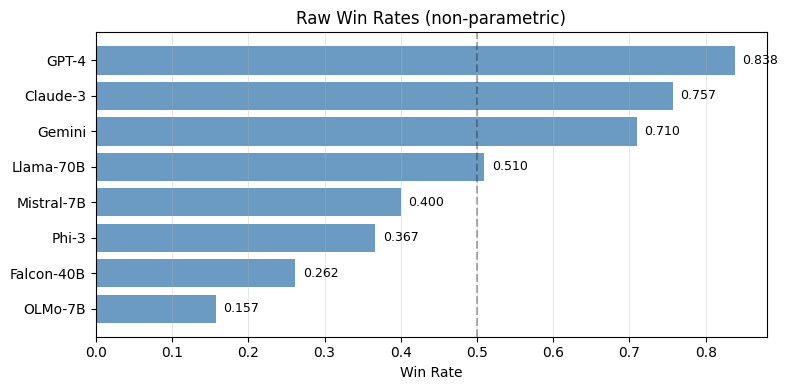

In [3]:
# Simple win rates (non-parametric baseline)
win_rates = comparisons.win_rates()

fig, ax = plt.subplots(figsize=(8, 4))
sorted_idx = win_rates.argsort(descending=True)
names_sorted = [model_names[i] for i in sorted_idx]
rates_sorted = win_rates[sorted_idx]

bars = ax.barh(range(n_subjects), rates_sorted.numpy(), color="steelblue", alpha=0.8)
ax.set_yticks(range(n_subjects))
ax.set_yticklabels(names_sorted)
ax.set_xlabel("Win Rate")
ax.set_title("Raw Win Rates (non-parametric)")
ax.axvline(x=0.5, color="k", linestyle="--", alpha=0.3)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")

for bar, rate in zip(bars, rates_sorted):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{rate:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

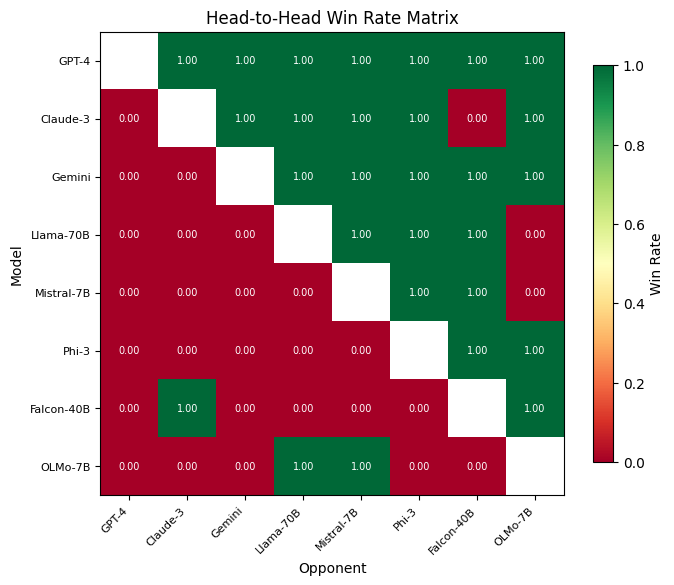

In [4]:
# Head-to-head win rate matrix
win_matrix = comparisons.to_win_matrix()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(win_matrix.numpy(), cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(n_subjects))
ax.set_yticks(range(n_subjects))
ax.set_xticklabels(model_names, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(model_names, fontsize=8)
ax.set_title("Head-to-Head Win Rate Matrix")
ax.set_xlabel("Opponent")
ax.set_ylabel("Model")

# Annotate cells
for i in range(n_subjects):
    for j in range(n_subjects):
        val = win_matrix[i, j].item()
        if not torch.isnan(win_matrix[i, j]):
            color = "white" if val > 0.7 or val < 0.3 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label="Win Rate")
plt.tight_layout()
plt.show()

## 4. Fitting the Bradley-Terry Model

The Bradley-Terry model estimates a single latent ability parameter $\theta_i$ for each model, such that $P(i > j) = \sigma(\theta_i - \theta_j)$. This is a parametric alternative to raw win rates that:

- Accounts for **opponent strength** (beating a strong opponent counts more)
- Enables **transitive predictions** (predict matchups that were never observed)
- Provides a **latent scale** for meaningful ability differences

In [5]:
# Fit with MLE
bt = BradleyTerry(n_subjects=n_subjects)
history = bt.fit(comparisons, method="mle", max_epochs=200, lr=0.05, verbose=False)

print(f"Converged in {len(history['losses'])} epochs")
print(f"Final loss: {history['losses'][-1]:.4f}")

Converged in 60 epochs
Final loss: 0.4743


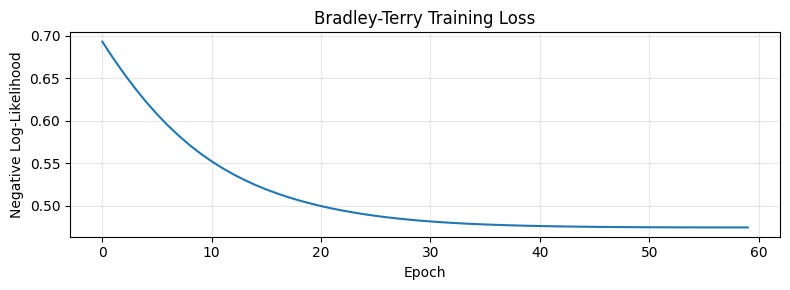

In [6]:
# Training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history["losses"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative Log-Likelihood")
ax.set_title("Bradley-Terry Training Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Estimated Abilities and Rankings

In [7]:
fitted_ability = bt.ability.detach()

# Print rankings
ranked_idx = fitted_ability.argsort(descending=True)
print("Bradley-Terry Rankings:")
print(f"{'Rank':>4}  {'Model':<15} {'BT Ability':>10} {'True Ability':>12} {'Win Rate':>9}")
print("-" * 56)
for rank, idx in enumerate(ranked_idx, 1):
    i = idx.item()
    print(f"{rank:4d}  {model_names[i]:<15} {fitted_ability[i]:+10.3f} {true_ability[i]:+12.3f} {win_rates[i]:9.3f}")

Bradley-Terry Rankings:
Rank  Model           BT Ability True Ability  Win Rate
--------------------------------------------------------
   1  GPT-4               +1.711       +2.000     0.838
   2  Claude-3            +1.233       +1.500     0.757
   3  Gemini              +0.958       +1.200     0.710
   4  Llama-70B           +0.004       +0.500     0.510
   5  Mistral-7B          -0.505       +0.000     0.400
   6  Phi-3               -0.670       -0.300     0.367
   7  Falcon-40B          -1.176       -0.800     0.262
   8  OLMo-7B             -1.788       -1.500     0.157


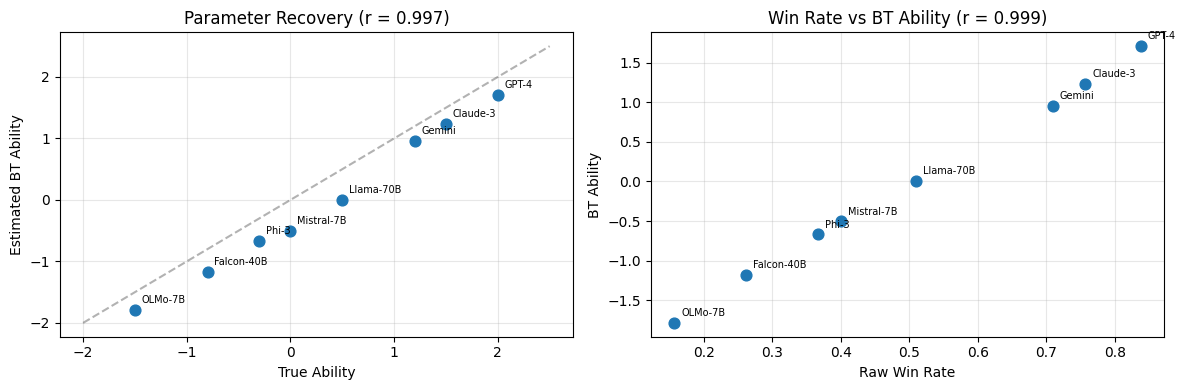

In [8]:
# Parameter recovery: fitted vs true abilities
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# BT ability vs true ability
r_bt = torch.corrcoef(torch.stack([true_ability, fitted_ability]))[0, 1]
axes[0].scatter(true_ability.numpy(), fitted_ability.numpy(), s=60, zorder=3)
for i in range(n_subjects):
    axes[0].annotate(model_names[i], (true_ability[i], fitted_ability[i]),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
axes[0].plot([-2, 2.5], [-2, 2.5], "k--", alpha=0.3)
axes[0].set_xlabel("True Ability")
axes[0].set_ylabel("Estimated BT Ability")
axes[0].set_title(f"Parameter Recovery (r = {r_bt:.3f})")
axes[0].grid(True, alpha=0.3)

# Win rate vs BT ability
r_wr = torch.corrcoef(torch.stack([win_rates, fitted_ability]))[0, 1]
axes[1].scatter(win_rates.numpy(), fitted_ability.numpy(), s=60, zorder=3)
for i in range(n_subjects):
    axes[1].annotate(model_names[i], (win_rates[i], fitted_ability[i]),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
axes[1].set_xlabel("Raw Win Rate")
axes[1].set_ylabel("BT Ability")
axes[1].set_title(f"Win Rate vs BT Ability (r = {r_wr:.3f})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Predictions: Win Probability Matrix

The fitted model can predict the probability of any matchup — even pairs that were never directly compared.

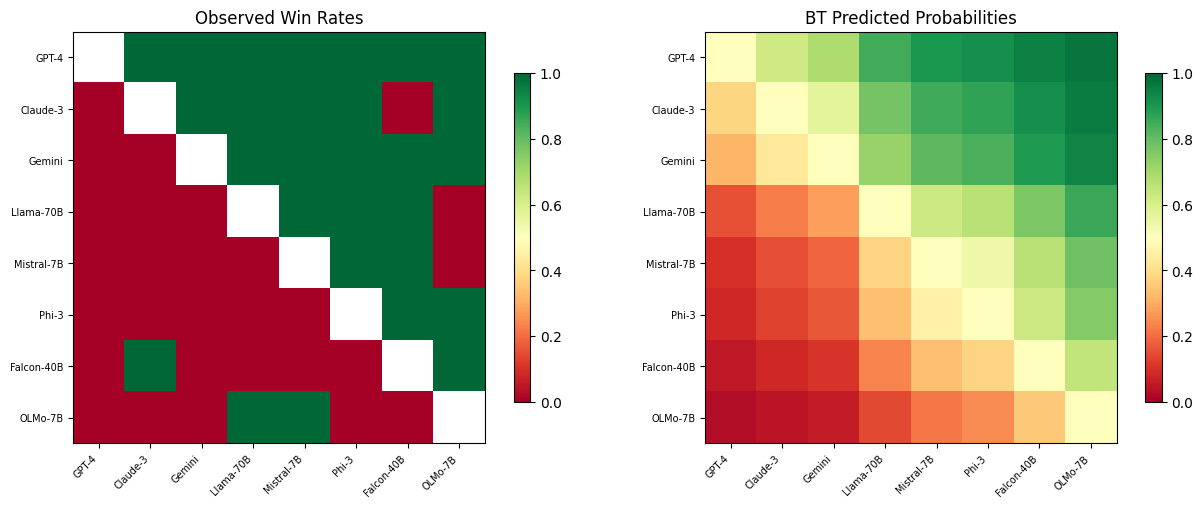

In [9]:
# Predicted vs observed win matrix
predicted_matrix = predict_dense(bt).detach()
observed_matrix = comparisons.to_win_matrix()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title in [(axes[0], observed_matrix, "Observed Win Rates"),
                        (axes[1], predicted_matrix, "BT Predicted Probabilities")]:
    im = ax.imshow(mat.numpy(), cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_xticks(range(n_subjects))
    ax.set_yticks(range(n_subjects))
    ax.set_xticklabels(model_names, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(model_names, fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

In [10]:
# Predict specific matchups
matchups = [("GPT-4", "Claude-3"), ("GPT-4", "OLMo-7B"), ("Mistral-7B", "Phi-3")]
print("Predicted win probabilities:")
for name_a, name_b in matchups:
    idx_a = model_names.index(name_a)
    idx_b = model_names.index(name_b)
    prob = bt.predict_pairwise(
        torch.tensor([idx_a]), torch.tensor([idx_b])
    ).item()
    print(f"  P({name_a} > {name_b}) = {prob:.3f}")

Predicted win probabilities:
  P(GPT-4 > Claude-3) = 0.617
  P(GPT-4 > OLMo-7B) = 0.971
  P(Mistral-7B > Phi-3) = 0.541


## 6. MLE vs JML Fitting

Bradley-Terry supports two fitting methods:
- **MLE** (Adam optimizer): fast, good for most cases
- **JML** (LBFGS + L2 regularization): adds shrinkage toward zero, useful when some models have few comparisons

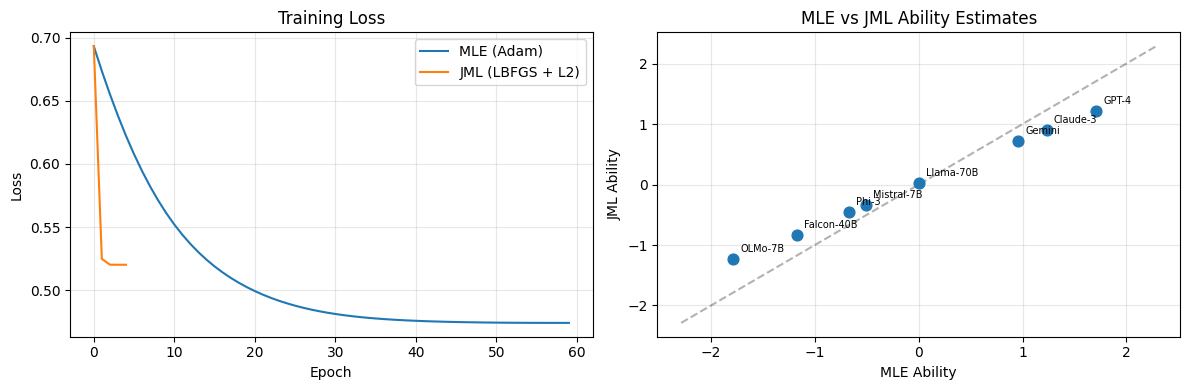

JML estimates are shrunk toward zero (regularization effect).


In [11]:
bt_mle = BradleyTerry(n_subjects=n_subjects)
bt_jml = BradleyTerry(n_subjects=n_subjects)

h_mle = bt_mle.fit(comparisons, method="mle", max_epochs=200, lr=0.05, verbose=False)
h_jml = bt_jml.fit(comparisons, method="jml", max_epochs=200, lr=0.1, regularization=0.05, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss comparison
axes[0].plot(h_mle["losses"], label="MLE (Adam)")
axes[0].plot(h_jml["losses"], label="JML (LBFGS + L2)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ability comparison
mle_ability = bt_mle.ability.detach()
jml_ability = bt_jml.ability.detach()
axes[1].scatter(mle_ability.numpy(), jml_ability.numpy(), s=60, zorder=3)
for i in range(n_subjects):
    axes[1].annotate(model_names[i], (mle_ability[i], jml_ability[i]),
                     textcoords="offset points", xytext=(5, 5), fontsize=7)
lim = max(abs(mle_ability).max(), abs(jml_ability).max()) + 0.5
axes[1].plot([-lim, lim], [-lim, lim], "k--", alpha=0.3)
axes[1].set_xlabel("MLE Ability")
axes[1].set_ylabel("JML Ability")
axes[1].set_title("MLE vs JML Ability Estimates")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("JML estimates are shrunk toward zero (regularization effect).")

## 7. Real Data: Building Pairwise Comparisons from MT-Bench

measurement-db's public catalog doesn't ship a ready-made pairwise comparison dataset, but we can synthesise one from [**MT-Bench**](https://arxiv.org/abs/2306.05685) — GPT-4 single-answer Likert (1-10) scores for 34 LLMs on 80 multi-turn prompts. For each prompt, any two models are compared: the model with the higher judge score "wins".

This is a lightweight bridge from the long-form `LongFormData` returned by `load()` to the `PairwiseComparisons` container consumed by `BradleyTerry`.

In [12]:
from torch_measure.datasets import load, info

# Inspect dataset metadata
mt_info = info("mtbench")
print(f"Dataset: {mt_info.name}")
print(f"Description: {mt_info.description}")
print(f"Response type: {mt_info.response_type}")

Dataset: mtbench
Description: MT-Bench GPT-4 single-answer judgment scores (34 models, 80 questions, 2 turns).
Response type: likert_10


In [13]:
# Download the dataset (long-form) and build pairwise comparisons from per-item judge scores.
mt = load("mtbench")
print(mt.responses.shape, "long-form rows")
print("Columns:", mt.responses.columns.tolist())

import pandas as pd

# Average over trial / test_condition per (subject, item) so we get one score per pair
scores = (
    mt.responses
    .groupby(["subject_id", "item_id"], as_index=False)["response"]
    .mean()
)

# Global subject index
subject_ids_list = sorted(mt.responses["subject_id"].unique().tolist())
subj_to_idx = {s: i for i, s in enumerate(subject_ids_list)}
item_ids_list = sorted(mt.responses["item_id"].unique().tolist())
item_to_idx = {it: i for i, it in enumerate(item_ids_list)}

# For each item, pair up all subjects; "A wins" if A's score > B's score
import itertools
a_idx, b_idx, outcome, item_idx = [], [], [], []
for it, group in scores.groupby("item_id"):
    g = group.set_index("subject_id")["response"].to_dict()
    subs = list(g.keys())
    for a, b in itertools.combinations(subs, 2):
        if g[a] == g[b]:
            continue  # skip ties for simplicity
        a_idx.append(subj_to_idx[a])
        b_idx.append(subj_to_idx[b])
        outcome.append(1.0 if g[a] > g[b] else 0.0)
        item_idx.append(item_to_idx[it])

arena = PairwiseComparisons(
    subject_a=torch.tensor(a_idx, dtype=torch.long),
    subject_b=torch.tensor(b_idx, dtype=torch.long),
    outcome=torch.tensor(outcome, dtype=torch.float32),
    item_idx=torch.tensor(item_idx, dtype=torch.long),
    subject_ids=subject_ids_list,
    item_ids=item_ids_list,
)

print(arena)
print(f"\nSubjects (models): {arena.n_subjects}")
print(f"Items (prompts):   {arena.n_items}")
print(f"Comparisons:       {arena.n_comparisons}")

(5436, 8) long-form rows
Columns: ['subject_id', 'item_id', 'benchmark_id', 'trial', 'test_condition', 'response', 'correct_answer', 'trace']
PairwiseComparisons(n_comparisons=63539, n_subjects=34, density=11326.02%)

Subjects (models): 34
Items (prompts):   160
Comparisons:       63539


### Subject & Item Information

`PairwiseComparisons` mirrors the `ResponseMatrix` pattern: subjects and items are first-class entity dimensions with `subject_ids`, `item_ids`, `item_contents`, and metadata. Each comparison maps to its subject pair via `subject_a`/`subject_b` indices and to its prompt via `item_idx`.

In [14]:
# --- Subject info ---
print("Subject IDs (first 5):", arena.subject_ids[:5])
print()

# Subject metadata (per-subject, indexed by position in subject_ids)
if arena.subject_metadata:
    print("Subject metadata (first 3):")
    for i in range(3):
        print(f"  {arena.subject_ids[i]}: {arena.subject_metadata[i]}")
print()

# --- Item info ---
print(f"Item IDs (first 5): {arena.item_ids[:5]}")
print()

# Item contents can be attached after construction from the LongFormData items registry
if arena.item_contents:
    print("Item contents (first 3 prompts):")
    for i in range(3):
        text = arena.item_contents[i]
        print(f"  [{arena.item_ids[i]}] {text[:80]}{'...' if len(text) > 80 else ''}")
else:
    print("(Item content strings not attached to this PairwiseComparisons; see mt.items for raw prompts.)")

Subject IDs (first 5): ['0196ad563000d719', '020e54b28482130a', '0c859822f2daa525', '13f57a871496e5c6', '1b1ae706971632ad']


Item IDs (first 5): ['010647982b275928', '0229c30a2425ff35', '038b7cf475e2b22b', '042275320e42715f', '04a3fc7d122b98dd']

(Item content strings not attached to this PairwiseComparisons; see mt.items for raw prompts.)


In [15]:
# --- Looking up a specific comparison ---
# Each comparison stores indices into subject_ids (via subject_a/subject_b)
# and into item_ids (via item_idx)

k = 42  # pick comparison #42
a_idx = arena.subject_a[k].item()
b_idx = arena.subject_b[k].item()
outcome = arena.outcome[k].item()

print(f"Comparison #{k}:")
print(f"  Subject A: {arena.subject_ids[a_idx]} (index {a_idx})")
print(f"  Subject B: {arena.subject_ids[b_idx]} (index {b_idx})")
print(f"  Outcome:   {'A wins' if outcome == 1.0 else 'B wins' if outcome == 0.0 else 'Tie'}")

if arena.item_idx is not None:
    item_i = arena.item_idx[k].item()
    print(f"  Prompt ID: {arena.item_ids[item_i]}")
    if arena.item_contents:
        text = arena.item_contents[item_i]
        print(f"  Prompt:    {text[:120]}{'...' if len(text) > 120 else ''}")

if arena.comparison_metadata:
    print(f"  Metadata:  {arena.comparison_metadata[k]}")

Comparison #42:
  Subject A: 0c859822f2daa525 (index 2)
  Subject B: 396841041ec65693 (index 10)
  Outcome:   B wins
  Prompt ID: 010647982b275928


In [16]:
# Fit Bradley-Terry on real arena data
bt_arena = BradleyTerry(n_subjects=arena.n_subjects)
history_arena = bt_arena.fit(arena, method="mle", max_epochs=200, lr=0.05, verbose=False)

print(f"Converged in {len(history_arena['losses'])} epochs")
print(f"Final loss: {history_arena['losses'][-1]:.4f}")

# Print rankings
ability_arena = bt_arena.ability.detach()
wr_arena = arena.win_rates()
ranked = ability_arena.argsort(descending=True)

print(f"\n{'Rank':>4}  {'Model':<28} {'BT Ability':>10} {'Win Rate':>9}")
print("-" * 55)
for rank, idx in enumerate(ranked, 1):
    i = idx.item()
    print(f"{rank:4d}  {arena.subject_ids[i]:<28} {ability_arena[i]:+10.3f} {wr_arena[i]:9.3f}")

Converged in 161 epochs
Final loss: 0.4543

Rank  Model                        BT Ability  Win Rate
-------------------------------------------------------
   1  1b1ae706971632ad                 +3.119     0.948
   2  020e54b28482130a                 +1.997     0.849
   3  744814b5b3011642                 +1.804     0.822
   4  fb7b3db03bd4645f                 +1.648     0.802
   5  6cfe96d3a65de687                 +1.569     0.789
   6  e6019a85dcd32e56                 +1.197     0.728
   7  bd722736a901c1ef                 +1.082     0.708
   8  b5306cf3206f6b66                 +0.901     0.673
   9  81010f8113da28bb                 +0.844     0.659
  10  58d992a0d42f8036                 +0.788     0.653
  11  282d18caec267f9a                 +0.786     0.647
  12  774056e52184fd68                 +0.720     0.637
  13  853441deeed4f7ed                 +0.710     0.635
  14  baa8cf04aa1d15d4                 +0.674     0.629
  15  396841041ec65693                 +0.647     0.619
  16

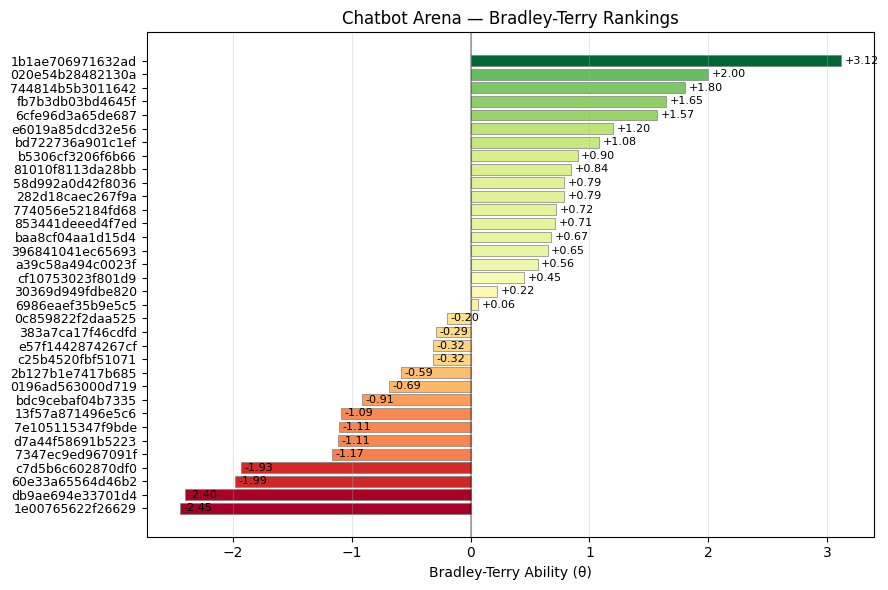

In [17]:
# Visualize the arena rankings
fig, ax = plt.subplots(figsize=(9, 6))
sorted_idx = ability_arena.argsort(descending=True)
names = [arena.subject_ids[i] for i in sorted_idx]
abilities = ability_arena[sorted_idx].numpy()

colors = plt.cm.RdYlGn((abilities - abilities.min()) / (abilities.max() - abilities.min()))
bars = ax.barh(range(len(names)), abilities, color=colors, edgecolor="gray", linewidth=0.5)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel("Bradley-Terry Ability (θ)")
ax.set_title("Chatbot Arena — Bradley-Terry Rankings")
ax.axvline(x=0, color="k", linestyle="-", alpha=0.3)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")

for bar, val in zip(bars, abilities):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Summary

| Feature | API |
|---------|-----|
| Data structure | `PairwiseComparisons(subject_a, subject_b, outcome, subject_ids)` |
| Subject info | `comparisons.subject_ids`, `comparisons.subject_metadata` |
| Item info | `comparisons.item_ids`, `comparisons.item_contents`, `comparisons.item_idx` |
| Counts | `comparisons.n_subjects`, `comparisons.n_items`, `comparisons.n_comparisons` |
| Win rates | `comparisons.win_rates()` |
| Win matrix | `comparisons.to_win_matrix()` |
| Model | `BradleyTerry(n_subjects)` |
| Fitting | `model.fit(comparisons, method="mle")` or `method="jml"` |
| Full prediction | `predict_dense(model)` → (n_subjects, n_subjects) matrix |
| Pair prediction | `model.predict_pairwise(a_idx, b_idx)` |
| Abilities | `model.ability` — learned latent strength per subject |
| Built-in data | `load("arena/chatbot_arena")` |

### Key Takeaways

- **Bradley-Terry > raw win rates** because it accounts for opponent strength. Beating GPT-4 is worth more than beating a weak model.
- **BT is Rasch for pairs** — same sigmoid, same MLE, but models compete against each other instead of answering items.
- **Transitive predictions** — even without observing every pair, the model can predict any matchup from the learned ability scale.
- **Parallel structure** — `PairwiseComparisons` mirrors `ResponseMatrix` with `subject_ids`/`item_ids`/`item_contents`, making subject and item lookup consistent across both data types.